In [130]:
from google.colab import files

uploaded = files.upload()

Saving test.csv to test.csv


In [134]:
import pandas as pd
import numpy as np

dataset = pd.read_csv('/content/transformed_train.csv')

dataset['timestamp'].unique()

array(['0:0', '0:15', '0:30', '0:45', '1:0', '1:15', '1:30', '1:45',
       '2:0', '2:15', '2:30', '2:45', '3:0', '3:15', '3:30', '3:45',
       '4:0', '4:15', '4:30', '4:45', '5:0', '5:15', '5:30', '5:45',
       '6:0', '6:15', '6:30', '6:45', '7:0', '7:15', '7:30', '7:45',
       '8:0', '8:15', '8:30', '8:45', '9:0', '9:15', '9:30', '9:45',
       '10:0', '10:15', '10:30', '10:45', '11:0', '11:15', '11:30',
       '11:45', '12:0', '12:15', '12:30', '12:45', '13:0', '13:15',
       '13:30', '13:45', '14:0', '14:15', '14:30', '14:45', '15:0',
       '15:15', '15:30', '15:45', '16:0', '16:15', '16:30', '16:45',
       '17:0', '17:15', '17:30', '17:45', '18:0', '18:15', '18:30',
       '18:45', '19:0', '19:15', '19:30', '19:45', '20:0', '20:15',
       '20:30', '20:45', '21:0', '21:15', '21:30', '21:45', '22:0',
       '22:15', '22:30', '22:45', '23:0', '23:15', '23:30', '23:45'],
      dtype=object)

# Changing timestamp to cyclic feature - using sine and cos

In [135]:
def time_to_minutes(time_str):
    h, m = map(int, time_str.split(':'))
    return h * 60 + m

dataset['minutes'] = dataset['timestamp'].apply(time_to_minutes)

dataset['sin_time'] = np.sin(2 * np.pi * dataset['minutes'] / 1440)
dataset['cos_time'] = np.cos(2 * np.pi * dataset['minutes'] / 1440)

dataset.drop(columns = ['timestamp', 'minutes', 'Index', 'Landmarks', 'LargeVehicles'], inplace = True)

dataset['Highway_x_Time'] = dataset['Road_Highway'] * dataset['sin_time']
dataset['Highway_x_Weather'] = dataset['Road_Highway'] * dataset['Weather_Rainy']
dataset['Rainy_Time'] = dataset['Weather_Rainy'] * dataset['sin_time']
dataset['Highway_x_foggy'] = dataset['Road_Highway'] * dataset['Weather_Foggy']
dataset['Residential_x_Time'] = dataset['Road_Residential'] * dataset['sin_time']
dataset['Residential_x_Weather'] = dataset['Road_Highway'] * dataset['Weather_Rainy']

In [114]:
dataset.describe()

,day,demand,NumberofLanes,Temperature,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Sunny,Road_Highway,Road_Residential,...,latitude,longitude,sin_time,cos_time,Highway_x_Time,Highway_x_Weather,Rainy_Time,Highway_x_foggy,Residential_x_Time,Residential_x_Weather
count,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,...,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000
mean,48.104240,0.109531,2.019312,16.635329,0.267599,0.275878,0.089432,0.367092,0.054291,0.885343,...,-5.350171,90.762834,0.213230,0.039678,0.014739,0.015197,0.058912,0.013998,0.180663,0.243637
std,0.305574,0.148769,0.918303,7.077744,0.442711,0.446959,0.285368,0.482016,0.226593,0.318611,...,0.056066,0.101504,0.615041,0.758089,0.146912,0.122337,0.336997,0.117483,0.586696,0.429280
min,48.000000,0.010000,1.000000,0.008332,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-5.484924,90.587769,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000
25%,48.000000,0.029440,1.000000,11.633042,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,-5.391541,90.675659,-0.258819,-0.751840,0.000000,0.000000,-0.000000,0.000000,-0.195090,0.000000
50%,48.000000,0.060752,2.000000,16.493521,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,-5.347595,90.752563,0.321439,0.065403,0.000000,0.000000,0.000000,0.000000,0.195090,0.000000
75%,48.000000,0.124693,3.000000,21.364938,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,...,-5.309143,90.851440,0.793353,0.866025,0.000000,0.000000,0.000000,0.000000,0.707107,0.000000
max,49.000000,1.000000,5.000000,48.251433,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,-5.237732,90.972290,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


###Removing some minority outliers

```
dataset = dataset[dataset['demand'] <= 0.5]
```


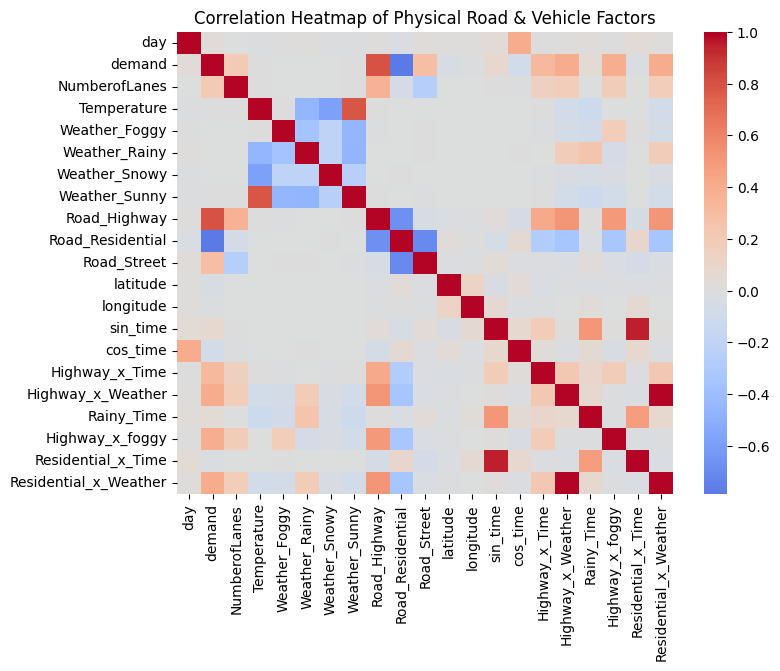

In [136]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = dataset.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Physical Road & Vehicle Factors")
plt.show()


In [119]:
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

X = dataset.drop(columns=['demand']).values
y = dataset['demand'].values.reshape(-1, 1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=1)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_x.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)

X_val_scaled = scaler_x.transform(X_val)
y_val_scaled = scaler_y.transform(y_val)

X_test_scaled = scaler_x.transform(X_test)
y_test_scaled = scaler_y.transform(y_test)

def to_tensor(x, y):
    x_t = torch.tensor(x, dtype=torch.float32).to(device)
    y_t = torch.tensor(y, dtype=torch.float32).to(device)
    return TensorDataset(x_t, y_t)

train_loader = DataLoader(to_tensor(X_train_scaled, y_train_scaled), batch_size=64, shuffle=True)
val_loader = DataLoader(to_tensor(X_val_scaled, y_val_scaled), batch_size=64, shuffle=False)
test_loader = DataLoader(to_tensor(X_test_scaled, y_test_scaled), batch_size=64, shuffle=False)

# 7. Model Definition
class DeepModel(nn.Module):
    def __init__(self, input_size):
        super(DeepModel, self).__init__()
        self.net = nn.Sequential(
            # First Block
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.15), # Drops 20% of neurons

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.1), # Drops 20% of neurons

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.1), # Drops 20% of neurons

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.1), # Drops 20% of neurons

            # Second Block
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.2), # Drops 20% of neurons

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.1), # Drops 20% of neurons

            # Output
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

In [120]:
model = DeepModel(input_size = X_train.shape[1])
model.to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.002)

In [121]:
pred_loss_arr = []
val_loss_arr = []
for epoch in range(200):
    model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        # Pass both as tensors
        predictions = model(batch_X)

        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    pred_loss_arr.append(avg_train_loss)

    # --- VALIDATION STEP ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for val_X, val_y in val_loader:

            # Pass both to the model
            val_preds = model(val_X)
            val_loss += criterion(val_preds, val_y).item()

    avg_val_loss = val_loss / len(val_loader)
    val_loss_arr.append(avg_val_loss)
    if(epoch <10):
        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Epoch 1 | Train Loss: 0.3202 | Val Loss: 0.2279
Epoch 2 | Train Loss: 0.2840 | Val Loss: 0.2248
Epoch 3 | Train Loss: 0.2671 | Val Loss: 0.2220
Epoch 4 | Train Loss: 0.2599 | Val Loss: 0.2220
Epoch 5 | Train Loss: 0.2586 | Val Loss: 0.2181
Epoch 6 | Train Loss: 0.2521 | Val Loss: 0.2117
Epoch 7 | Train Loss: 0.2474 | Val Loss: 0.2088
Epoch 8 | Train Loss: 0.2540 | Val Loss: 0.2050
Epoch 9 | Train Loss: 0.2425 | Val Loss: 0.2030
Epoch 10 | Train Loss: 0.2404 | Val Loss: 0.2030
Epoch 10 | Train Loss: 0.2404 | Val Loss: 0.2030
Epoch 20 | Train Loss: 0.2192 | Val Loss: 0.1943
Epoch 30 | Train Loss: 0.2108 | Val Loss: 0.1815
Epoch 40 | Train Loss: 0.2049 | Val Loss: 0.1845
Epoch 50 | Train Loss: 0.2002 | Val Loss: 0.1779
Epoch 60 | Train Loss: 0.2037 | Val Loss: 0.1768
Epoch 70 | Train Loss: 0.1996 | Val Loss: 0.1794
Epoch 80 | Train Loss: 0.1974 | Val Loss: 0.1838
Epoch 90 | Train Loss: 0.1931 | Val Loss: 0.1856
Epoch 100 | Train Loss: 0.1920 | Val Loss: 0.1886
Epoch 110 | Train Loss: 0.19

In [122]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        preds = model(batch_X)
        all_preds.append(preds)
        all_targets.append(batch_y)

# Concatenate all batches into full tensors
y_pred_all = torch.cat(all_preds)
y_true_all = torch.cat(all_targets)

# Now calculate metrics on the full sets
mse_baseline = torch.mean((y_true_all - y_true_all.mean())**2)
mse_model = torch.mean((y_true_all - y_pred_all)**2)

r_squared = 1 - (mse_model / mse_baseline)

print(f"Baseline Loss (MSE): {mse_baseline.item():.4f}")
print(f"Model Loss (MSE):    {mse_model.item():.4f}")
print(f"R-squared:           {r_squared.item():.4f}")

Baseline Loss (MSE): 1.0109
Model Loss (MSE):    0.1762
R-squared:           0.8257


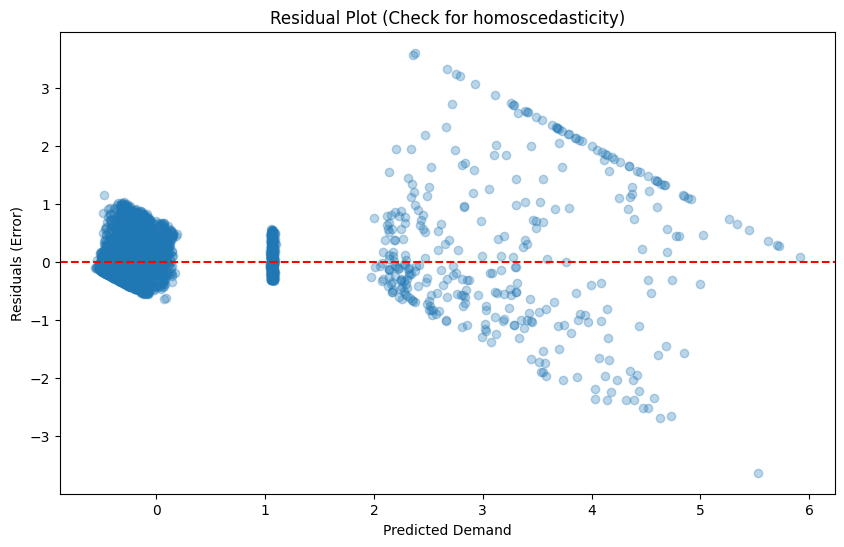

In [123]:
import matplotlib.pyplot as plt

# 1. Ensure the model is in evaluation mode
model.eval()

# 2. Generate predictions on the test set
with torch.no_grad():
    # Use the test loader to get predictions for the unseen data
    all_preds = []
    all_actuals = []
    for batch_X, batch_y in test_loader:
        preds = model(batch_X)
        all_preds.append(preds.cpu())
        all_actuals.append(batch_y.cpu())

    # Concatenate all batches into single arrays
    preds_np = torch.cat(all_preds).numpy()
    actuals_np = torch.cat(all_actuals).numpy()

# 3. Calculate residuals
residuals = actuals_np - preds_np  # Residual = Actual - Predicted

# 4. Plot
plt.figure(figsize=(10, 6))
plt.scatter(preds_np, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot (Check for homoscedasticity)")
plt.xlabel("Predicted Demand")
plt.ylabel("Residuals (Error)")
plt.show()

In [124]:
# 1. Create a DataFrame for analysis (ensure you have your features available)
analysis_df = pd.DataFrame(X_test) # Use your actual column names
analysis_df['residuals'] = actuals_np - preds_np
analysis_df['preds'] = preds_np

# 2. Isolate the "Problematic" 3rd Cluster (where preds > 2.5)
cluster_3 = analysis_df[analysis_df['preds'] > 2.5]

# 3. Compare stats
print("--- Cluster 3 Average Features ---")
print(cluster_3.mean())

print("\n--- Entire Dataset Average Features ---")
print(analysis_df.mean())

--- Cluster 3 Average Features ---
0            48.133891
1             3.476987
2            16.655190
3             0.196653
4             0.301255
5             0.087866
6             0.414226
7             1.000000
8             0.000000
9             0.000000
10           -5.344492
11           90.770031
12            0.217796
13           -0.203906
14            0.217796
15            0.301255
16            0.065278
17            0.196653
18            0.000000
19            0.000000
residuals     0.135103
preds         3.638753
dtype: float64

--- Entire Dataset Average Features ---
0            48.102867
1             2.014580
2            16.706821
3             0.257087
4             0.275069
5             0.092500
6             0.375344
7             0.054593
8             0.884335
9             0.061072
10           -5.350451
11           90.764564
12            0.217368
13            0.038789
14            0.011960
15            0.016524
16            0.058124
17          

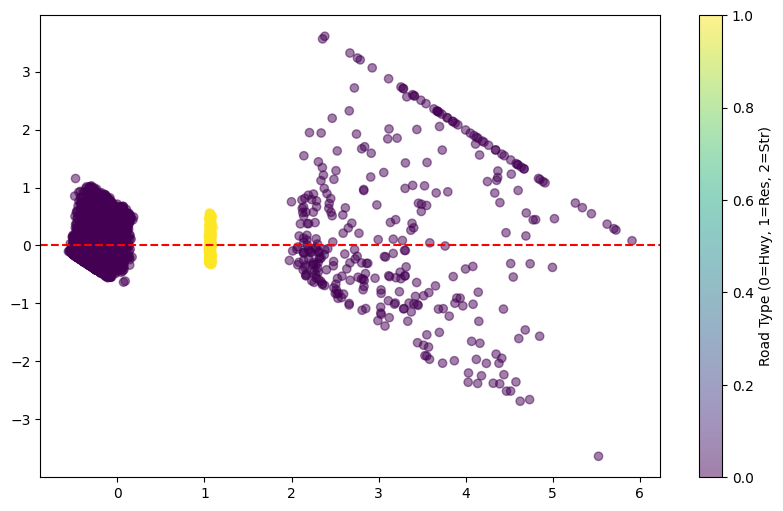

In [125]:
# 1. Identify the indices of your OHE columns in your feature set
# Replace these with the actual column indices in your X_test array
ohe_indices = [8, 9, 10]

# 2. Extract those columns and convert to category labels (0, 1, 2)
# axis=1 tells numpy to look across the columns for each row
color_labels = np.argmax(X_test[:, ohe_indices], axis=1)

# 3. Now pass this to your plot
plt.figure(figsize=(10, 6))
plt.scatter(preds_np, residuals, c=color_labels, cmap='viridis', alpha=0.5)
plt.colorbar(label='Road Type (0=Hwy, 1=Res, 2=Str)')
plt.axhline(0, color='red', linestyle='--')
plt.show()

In [126]:
actuals_np

array([[-0.11673237],
       [-0.58679974],
       [ 0.42396897],
       ...,
       [-0.26579657],
       [-0.2548049 ],
       [-0.28264678]], dtype=float32)

In [127]:
preds_np

array([[-0.34477532],
       [-0.37810153],
       [-0.13219814],
       ...,
       [-0.11686872],
       [-0.15020831],
       [-0.21943964]], dtype=float32)

In [128]:
df = pd.DataFrame(preds_np)
df2 = pd.DataFrame(actuals_np)

df2.describe()

,0
count,6173.000000
mean,0.005683
std,1.005520
min,-0.668565
25%,-0.537332
50%,-0.313322
75%,0.098374
max,5.992474


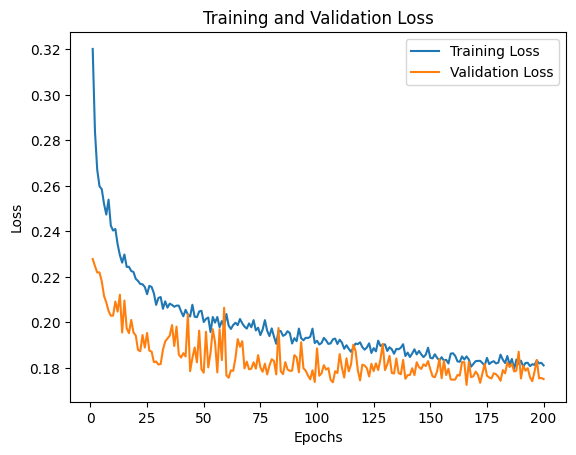

In [129]:
epochs = range(1, len(pred_loss_arr) + 1)

plt.plot(epochs, pred_loss_arr, label='Training Loss')
plt.plot(epochs, val_loss_arr, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()